# MoonBoard GNN Grade Prediction Experiment

This notebook is the main self-contained experiment notebook. It predicts the difficulty grade of a MoonBoard 2016 climbing problem from its hold configuration by converting each problem into a graph and training a GNN classifier.

All core logic is embedded in this notebook, so it can run without importing `run_moonboard_gnn.py`. For Colab, upload the dataset files listed below to the same working directory before running the experiment cells.


## Included Data

Required local files in the same directory as this notebook:

- `moonGen_scrape_2016_final`: MoonBoardRNN raw 2016 pickle dataset.
- `HoldFeature2016LeftHand.csv` and `HoldFeature2016RightHand.csv`: optional expert hold difficulty features from MoonBoardRNN.
- `experiment_summary_preliminary.csv`: previously recorded short-run results.

The main labels use the same grade mapping as MoonBoardRNN: `6B/6B+ -> 0`, `6C/6C+ -> 1`, ..., `8B -> 9`.


## Optional Colab Setup

Run the next cell in Colab if the required packages are missing. If your runtime already has these packages, you can skip it.


In [1]:
# Optional: uncomment in Colab if dependencies are missing.
!pip install -q torch-geometric scikit-learn pandas tqdm


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.7/63.7 kB 2.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 31.5 MB/s eta 0:00:00


In [2]:
from pathlib import Path

ROOT = Path.cwd()
print("working directory:", ROOT)
for name in ["moonGen_scrape_2016_final", "HoldFeature2016LeftHand.csv", "HoldFeature2016RightHand.csv"]:
    path = ROOT / name
    print(f"{name}: exists={path.exists()} size={path.stat().st_size if path.exists() else 'missing'}")


working directory: /content
moonGen_scrape_2016_final: exists=True size=18644006
HoldFeature2016LeftHand.csv: exists=True size=1379
HoldFeature2016RightHand.csv: exists=True size=1097


## Core Implementation

This cell defines data loading, graph construction, GNN models, training, and evaluation. It is copied from the project script so the notebook can run without importing a separate local module.


In [3]:
from __future__ import annotations

import argparse
import csv
import json
import pickle
import random
import time

try:
    from tqdm import tqdm
except Exception:
    tqdm = None
from collections import Counter
from dataclasses import dataclass
from pathlib import Path

import numpy as np
import torch
import torch.nn.functional as F
from sklearn.metrics import accuracy_score, f1_score
from sklearn.model_selection import train_test_split
from torch import nn
from torch_geometric.data import Data
from torch_geometric.loader import DataLoader
from torch_geometric.nn import GATConv, GCNConv, SAGEConv, global_max_pool


GRADE_MAP = {
    "6B": 0,
    "6B+": 0,
    "6C": 1,
    "6C+": 1,
    "7A": 2,
    "7A+": 3,
    "7B": 4,
    "7B+": 4,
    "7C": 5,
    "7C+": 6,
    "8A": 7,
    "8A+": 8,
    "8B": 9,
}

HOLD_DIRECTION_RAW = """
1 - H7 - SE
2 - J14 - NW
3 - K7 - N
4 - D8 - N
5 - A16 - NW
6 - F6 - E
7 - K6 - N
8 - C9 - W
9 - A10 - SW
10 - I8 - N
11 - K12 - N
12 - A11 - SE
13 - B7 - S
14 - D16 - N
15 - K10 - S
16 - G16 - N
17 - F8 - N
18 - F15 - N
19 - G7 - SW
20 - H15 - NE
21 - C12 - N
22 - D6 - N
23 - D3 - S
24 - D13 - N
25 - J11 - N
26 - A13 - N
27 - G11 - E
28 - H18 - N
29 - B4 - SW
30 - K8 - N
31 - C15 - NW
32 - H9 - E
33 - D10 - NW
34 - H14 - W
35 - I5 - N
36 - I12 - SW
37 - K13 - N
38 - C7 - N
39 - C18 - N
40 - F9 - N
50 - C14 - N
51 - D17 - N
52 - D9 - NE
53 - F7 - NW
54 - F12 - E
55 - G12 - NE
56 - B11 - NW
57 - J10 - NE
58 - J2 - SE
59 - E13 - N
60 - I6 - NE
61 - J9 - SE
62 - F14 - NW
63 - I13 - E
64 - E10 - NW
65 - F10 - NE
66 - E15 - NW
67 - B8 - N
68 - A12 - E
69 - I16 - NE
70 - I11 - N
71 - B16 - NW
72 - E11 - N
73 - H11 - W
74 - E7 - S
75 - D12 - N
76 - J8 - N
77 - B13 - NW
78 - B9 - NE
79 - C10 - NE
80 - B3 - SW
81 - G2 - N
82 - G18 - W
83 - I4 - NE
84 - K11 - NW
85 - A5 - N
86 - K5 - N
87 - K18 - W
88 - G8 - N
89 - F5 - N
90 - G13 - N
91 - E18 - N
92 - J6 - S
93 - D14 - N
94 - C11 - W
95 - C6 - S
96 - F16 - S
97 - D5 - NW
98 - A15 - N
99 - B18 - SE
100 - H16 - N
101 - B15 - N
102 - J12 - NE
103 - J13 - N
104 - K16 - N
105 - F13 - NW
106 - E16 - NW
107 - I7 - NE
108 - I15 - NW
109 - I9 - SE
110 - E12 - NE
111 - H5 - NW
112 - G15 - NW
113 - J7 - N
114 - H12 - NW
115 - G17 - N
116 - E9 - NE
117 - J16 - E
118 - F11 - NE
119 - D11 - SW
120 - I10 - N
121 - K9 - N
122 - E8 - N
123 - A14 - NW
124 - I14 - NW
125 - C5 - N
126 - D15 - NW
127 - E14 - E
128 - G9 - NE
129 - E6 - NW
130 - J5 - NW
131 - H8 - NE
132 - I18 - NE
133 - A9 - NW
134 - G6 - SW
135 - C8 - NW
136 - D18 - N
137 - G14 - E
138 - C13 - NW
139 - A18 - N
140 - H10 - NE
141 - G4 - N
142 - B12 - SE
143 - C16 - N
144 - K14 - NE
145 - G10 - NE
146 - D7 - S
147 - B6 - NW
148 - B10 - SE
149 - H13 - SW
"""

DIRECTION_VECTORS = {
    "N": (0.0, 1.0),
    "NE": (0.707, 0.707),
    "E": (1.0, 0.0),
    "SE": (0.707, -0.707),
    "S": (0.0, -1.0),
    "SW": (-0.707, -0.707),
    "W": (-1.0, 0.0),
    "NW": (-0.707, 0.707),
}


def build_hold_direction_map() -> dict[tuple[int, int], tuple[float, float]]:
    result = {}
    for line in HOLD_DIRECTION_RAW.strip().splitlines():
        parts = [p.strip() for p in line.split(" - ")]
        if len(parts) != 3:
            continue
        hold = parts[1]
        direction = parts[2]
        x = ord(hold[0].upper()) - ord("A")
        # MoonBoardRNN raw data stores y as zero-based board coordinates,
        # while hold strings such as A5 are one-based.
        y = int(hold[1:]) - 1
        result[(x, y)] = DIRECTION_VECTORS[direction]
    return result


HOLD_DIRECTIONS = build_hold_direction_map()


@dataclass(frozen=True)
class Problem:
    key: str
    grade: str
    label: int
    start: tuple[tuple[int, int], ...]
    mid: tuple[tuple[int, int], ...]
    end: tuple[tuple[int, int], ...]
    is_benchmark: bool


def seed_everything(seed: int) -> None:
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)


def load_hold_difficulties(path: Path) -> dict[tuple[int, int], float]:
    values: dict[tuple[int, int], float] = {}
    with path.open("r", encoding="utf-8-sig", newline="") as f:
        reader = csv.DictReader(f)
        for row in reader:
            if not row.get("X_coord") or not row.get("Y_coord"):
                continue
            x = int(float(row["X_coord"]))
            y = int(float(row["Y_coord"]))
            diff = float(row["Difficulties"])
            values[(x, y)] = diff
    return values


def load_problems(
    raw_path: Path,
    dataset: str,
    max_samples: int | None,
    seed: int,
) -> list[Problem]:
    raw = pickle.load(raw_path.open("rb"))
    problems: list[Problem] = []
    for key, item in raw.items():
        grade = item.get("grade")
        if grade not in GRADE_MAP:
            continue
        if dataset == "benchmark" and not item.get("is_benchmark"):
            continue
        if dataset == "nonbenchmark" and item.get("is_benchmark"):
            continue
        start = tuple(tuple(map(int, hold)) for hold in item.get("start", []))
        mid = tuple(tuple(map(int, hold)) for hold in item.get("mid", []))
        end = tuple(tuple(map(int, hold)) for hold in item.get("end", []))
        if not start or not end:
            continue
        problems.append(
            Problem(
                key=str(key),
                grade=grade,
                label=GRADE_MAP[grade],
                start=start,
                mid=mid,
                end=end,
                is_benchmark=bool(item.get("is_benchmark")),
            )
        )

    rng = random.Random(seed)
    rng.shuffle(problems)
    if max_samples is not None:
        problems = problems[:max_samples]
    return problems


def ordered_holds(problem: Problem, order_mode: str) -> list[tuple[tuple[int, int], str]]:
    start = sorted(problem.start, key=lambda xy: (xy[1], xy[0]))
    mid = list(problem.mid)
    end = sorted(problem.end, key=lambda xy: (xy[1], xy[0]))

    if order_mode == "source":
        # Raw scrape stores start/mid/end separately. Preserve mid order.
        mid_ordered = mid
    elif order_mode == "height":
        mid_ordered = sorted(mid, key=lambda xy: (xy[1], xy[0]))
    elif order_mode == "none":
        mid_ordered = sorted(mid, key=lambda xy: (xy[0], xy[1]))
    else:
        raise ValueError(f"unknown order_mode: {order_mode}")

    return (
        [(xy, "start") for xy in start]
        + [(xy, "mid") for xy in mid_ordered]
        + [(xy, "end") for xy in end]
    )


def node_feature(
    xy: tuple[int, int],
    hold_type: str,
    position: int,
    n_holds: int,
    feature_set: str,
    left_diff: dict[tuple[int, int], float],
    right_diff: dict[tuple[int, int], float],
) -> list[float]:
    x, y = xy
    feat = [x / 10.0, y / 17.0]

    if feature_set in {
        "type",
        "type_order",
        "direction",
        "direction_order",
        "difficulty",
        "difficulty_order",
        "difficulty_direction",
        "difficulty_direction_order",
    }:
        feat.extend(
            [
                1.0 if hold_type == "start" else 0.0,
                1.0 if hold_type == "mid" else 0.0,
                1.0 if hold_type == "end" else 0.0,
            ]
        )

    if feature_set in {
        "direction",
        "direction_order",
        "difficulty_direction",
        "difficulty_direction_order",
    }:
        feat.extend(HOLD_DIRECTIONS.get(xy, (0.0, 1.0)))

    if feature_set in {
        "difficulty",
        "difficulty_order",
        "difficulty_direction",
        "difficulty_direction_order",
    }:
        feat.extend(
            [
                left_diff.get(xy, 0.0) / 10.0,
                right_diff.get(xy, 0.0) / 10.0,
            ]
        )

    if feature_set in {
        "type_order",
        "direction_order",
        "difficulty_order",
        "difficulty_direction_order",
    }:
        denom = max(1, n_holds - 1)
        feat.append(position / denom)

    return feat


def create_edges(
    holds: list[tuple[tuple[int, int], str]],
    edge_mode: str,
    reach_threshold: float,
) -> torch.Tensor:
    edge_set: set[tuple[int, int]] = set()
    coords = [xy for xy, _ in holds]

    if edge_mode in {"spatial", "hybrid"}:
        for i, (xi, yi) in enumerate(coords):
            for j, (xj, yj) in enumerate(coords):
                if i == j:
                    continue
                dist = ((xi - xj) ** 2 + (yi - yj) ** 2) ** 0.5 / ((10**2 + 17**2) ** 0.5)
                if dist <= reach_threshold:
                    edge_set.add((i, j))

    if edge_mode in {"sequence", "hybrid"}:
        for i in range(len(holds) - 1):
            edge_set.add((i, i + 1))
            # Add reverse edge so message passing is not one-way brittle.
            edge_set.add((i + 1, i))

    if not edge_set:
        for i in range(len(holds)):
            edge_set.add((i, i))

    edge_index = torch.tensor(sorted(edge_set), dtype=torch.long).t().contiguous()
    return edge_index


def problem_to_graph(
    problem: Problem,
    feature_set: str,
    edge_mode: str,
    order_mode: str,
    reach_threshold: float,
    left_diff: dict[tuple[int, int], float],
    right_diff: dict[tuple[int, int], float],
) -> Data:
    holds = ordered_holds(problem, order_mode)
    features = [
        node_feature(
            xy=xy,
            hold_type=hold_type,
            position=i,
            n_holds=len(holds),
            feature_set=feature_set,
            left_diff=left_diff,
            right_diff=right_diff,
        )
        for i, (xy, hold_type) in enumerate(holds)
    ]
    x = torch.tensor(features, dtype=torch.float32)
    edge_index = create_edges(holds, edge_mode=edge_mode, reach_threshold=reach_threshold)
    y = torch.tensor([problem.label], dtype=torch.long)
    data = Data(x=x, edge_index=edge_index, y=y)
    data.problem_key = problem.key
    data.grade = problem.grade
    return data


class GATClassifier(nn.Module):
    def __init__(self, in_channels: int, hidden_channels: int, num_classes: int):
        super().__init__()
        self.conv1 = GATConv(in_channels, hidden_channels, heads=4, concat=False)
        self.conv2 = GATConv(hidden_channels, hidden_channels, heads=4, concat=False)
        self.mlp = nn.Sequential(
            nn.Linear(hidden_channels, hidden_channels),
            nn.ELU(),
            nn.Dropout(p=0.5),
            nn.Linear(hidden_channels, hidden_channels // 2),
            nn.ELU(),
            nn.Dropout(p=0.5),
            nn.Linear(hidden_channels // 2, num_classes),
        )

    def forward(self, x, edge_index, batch):
        x = self.conv1(x, edge_index)
        x = F.elu(x)
        x = F.dropout(x, p=0.5, training=self.training)
        x = self.conv2(x, edge_index)
        x = F.elu(x)
        x = global_max_pool(x, batch)
        return self.mlp(x)


class GCNClassifier(nn.Module):
    def __init__(self, in_channels: int, hidden_channels: int, num_classes: int):
        super().__init__()
        self.conv1 = GCNConv(in_channels, hidden_channels)
        self.conv2 = GCNConv(hidden_channels, hidden_channels)
        self.mlp = nn.Sequential(
            nn.Linear(hidden_channels, hidden_channels),
            nn.ReLU(),
            nn.Dropout(p=0.5),
            nn.Linear(hidden_channels, num_classes),
        )

    def forward(self, x, edge_index, batch):
        x = F.relu(self.conv1(x, edge_index))
        x = F.dropout(x, p=0.5, training=self.training)
        x = F.relu(self.conv2(x, edge_index))
        x = global_max_pool(x, batch)
        return self.mlp(x)


class SAGEClassifier(nn.Module):
    def __init__(self, in_channels: int, hidden_channels: int, num_classes: int):
        super().__init__()
        self.conv1 = SAGEConv(in_channels, hidden_channels)
        self.conv2 = SAGEConv(hidden_channels, hidden_channels)
        self.mlp = nn.Sequential(
            nn.Linear(hidden_channels, hidden_channels),
            nn.ReLU(),
            nn.Dropout(p=0.5),
            nn.Linear(hidden_channels, num_classes),
        )

    def forward(self, x, edge_index, batch):
        x = F.relu(self.conv1(x, edge_index))
        x = F.dropout(x, p=0.5, training=self.training)
        x = F.relu(self.conv2(x, edge_index))
        x = global_max_pool(x, batch)
        return self.mlp(x)


def make_model(model_name: str, in_channels: int, hidden_channels: int, num_classes: int) -> nn.Module:
    if model_name == "gat":
        return GATClassifier(in_channels, hidden_channels, num_classes)
    if model_name == "gcn":
        return GCNClassifier(in_channels, hidden_channels, num_classes)
    if model_name == "sage":
        return SAGEClassifier(in_channels, hidden_channels, num_classes)
    raise ValueError(f"unknown model: {model_name}")


def evaluate(model: nn.Module, loader: DataLoader, device: torch.device) -> dict[str, float]:
    model.eval()
    y_true: list[int] = []
    y_pred: list[int] = []
    with torch.no_grad():
        for batch in loader:
            batch = batch.to(device)
            pred = model(batch.x, batch.edge_index, batch.batch).argmax(dim=1)
            y_true.extend(batch.y.cpu().tolist())
            y_pred.extend(pred.cpu().tolist())
    exact = accuracy_score(y_true, y_pred)
    relaxed = float(np.mean(np.abs(np.array(y_true) - np.array(y_pred)) <= 1))
    macro_f1 = f1_score(y_true, y_pred, average="macro", zero_division=0)
    return {"exact_acc": exact, "relaxed_acc": relaxed, "macro_f1": macro_f1}


def train_model(
    model: nn.Module,
    train_loader: DataLoader,
    val_loader: DataLoader,
    test_loader: DataLoader,
    epochs: int,
    lr: float,
    device: torch.device,
) -> tuple[dict[str, float], list[dict[str, float]]]:
    optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=5e-4)
    criterion = nn.CrossEntropyLoss()
    history = []
    best_val = -1.0
    best_state = None

    model.to(device)
    epoch_iter = range(1, epochs + 1)
    if tqdm is not None:
        epoch_iter = tqdm(epoch_iter, total=epochs, desc="Training epochs")
    for epoch in epoch_iter:
        model.train()
        total_loss = 0.0
        batch_iter = train_loader
        if tqdm is not None:
            batch_iter = tqdm(train_loader, total=len(train_loader), desc=f"Epoch {epoch:03d}", leave=False)
        for batch in batch_iter:
            batch = batch.to(device)
            optimizer.zero_grad()
            out = model(batch.x, batch.edge_index, batch.batch)
            loss = criterion(out, batch.y)
            loss.backward()
            optimizer.step()
            total_loss += float(loss.item()) * batch.num_graphs

        train_loss = total_loss / len(train_loader.dataset)
        val_metrics = evaluate(model, val_loader, device)
        row = {"epoch": epoch, "loss": train_loss, **{f"val_{k}": v for k, v in val_metrics.items()}}
        history.append(row)
        if val_metrics["relaxed_acc"] > best_val:
            best_val = val_metrics["relaxed_acc"]
            best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}

        msg = (
            f"epoch={epoch:03d} loss={train_loss:.4f} "
            f"val_exact={val_metrics['exact_acc']:.4f} "
            f"val_relaxed={val_metrics['relaxed_acc']:.4f} "
            f"val_macro_f1={val_metrics['macro_f1']:.4f}"
        )
        if tqdm is not None and hasattr(epoch_iter, "set_postfix"):
            epoch_iter.set_postfix(
                loss=f"{train_loss:.4f}",
                val_exact=f"{val_metrics['exact_acc']:.4f}",
                val_pm1=f"{val_metrics['relaxed_acc']:.4f}",
                val_f1=f"{val_metrics['macro_f1']:.4f}",
            )
            tqdm.write(msg)
        else:
            print(msg)

    if best_state is not None:
        model.load_state_dict(best_state)
        model.to(device)
    test_metrics = evaluate(model, test_loader, device)
    return test_metrics, history


def majority_baseline(labels: list[int], test_labels: list[int]) -> dict[str, float]:
    majority = Counter(labels).most_common(1)[0][0]
    pred = np.full(len(test_labels), majority)
    true = np.array(test_labels)
    return {
        "exact_acc": float(np.mean(pred == true)),
        "relaxed_acc": float(np.mean(np.abs(pred - true) <= 1)),
        "macro_f1": f1_score(true, pred, average="macro", zero_division=0),
    }


def write_json(path: Path, value) -> None:
    path.write_text(json.dumps(value, indent=2, ensure_ascii=False), encoding="utf-8")


def main() -> None:
    parser = argparse.ArgumentParser(description="MoonBoardRNN raw-data GNN grade prediction experiment.")
    parser.add_argument("--raw", type=Path, default=Path("moonGen_scrape_2016_final"))
    parser.add_argument("--left-diff", type=Path, default=Path("HoldFeature2016LeftHand.csv"))
    parser.add_argument("--right-diff", type=Path, default=Path("HoldFeature2016RightHand.csv"))
    parser.add_argument("--output-dir", type=Path, default=Path("outputs"))
    parser.add_argument("--dataset", choices=["all", "benchmark", "nonbenchmark"], default="all")
    parser.add_argument("--max-samples", type=int, default=5000)
    parser.add_argument(
        "--feature-set",
        choices=[
            "xy",
            "type",
            "type_order",
            "direction",
            "direction_order",
            "difficulty",
            "difficulty_order",
            "difficulty_direction",
            "difficulty_direction_order",
        ],
        default="difficulty",
    )
    parser.add_argument("--edge-mode", choices=["spatial", "sequence", "hybrid"], default="hybrid")
    parser.add_argument("--order-mode", choices=["source", "height", "none"], default="source")
    parser.add_argument("--model", choices=["gat", "gcn", "sage"], default="gat")
    parser.add_argument("--reach-threshold", type=float, default=0.4)
    parser.add_argument("--epochs", type=int, default=10)
    parser.add_argument("--batch-size", type=int, default=64)
    parser.add_argument("--hidden", type=int, default=64)
    parser.add_argument("--lr", type=float, default=0.005)
    parser.add_argument("--seed", type=int, default=471)
    args = parser.parse_args()

    total_start = time.perf_counter()
    seed_everything(args.seed)
    args.output_dir.mkdir(parents=True, exist_ok=True)

    left_diff = load_hold_difficulties(args.left_diff)
    right_diff = load_hold_difficulties(args.right_diff)
    problems = load_problems(args.raw, args.dataset, args.max_samples, args.seed)
    labels = [p.label for p in problems]

    train_val_idx, test_idx = train_test_split(
        np.arange(len(problems)),
        test_size=0.2,
        random_state=args.seed,
        stratify=labels,
    )
    train_idx, val_idx = train_test_split(
        train_val_idx,
        test_size=0.2,
        random_state=args.seed,
        stratify=[labels[i] for i in train_val_idx],
    )

    graphs = [
        problem_to_graph(
            problem=p,
            feature_set=args.feature_set,
            edge_mode=args.edge_mode,
            order_mode=args.order_mode,
            reach_threshold=args.reach_threshold,
            left_diff=left_diff,
            right_diff=right_diff,
        )
        for p in problems
    ]

    train_set = [graphs[i] for i in train_idx]
    val_set = [graphs[i] for i in val_idx]
    test_set = [graphs[i] for i in test_idx]

    train_loader = DataLoader(train_set, batch_size=args.batch_size, shuffle=True)
    val_loader = DataLoader(val_set, batch_size=args.batch_size)
    test_loader = DataLoader(test_set, batch_size=args.batch_size)

    in_channels = graphs[0].num_node_features
    num_classes = max(labels) + 1
    model = make_model(args.model, in_channels, args.hidden, num_classes)
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

    majority = majority_baseline([labels[i] for i in train_idx], [labels[i] for i in test_idx])
    print("config:", vars(args))
    print("device:", device)
    print("num problems:", len(problems))
    print("label distribution:", dict(sorted(Counter(labels).items())))
    print("node features:", in_channels)
    print("majority baseline:", majority)

    test_metrics, history = train_model(
        model=model,
        train_loader=train_loader,
        val_loader=val_loader,
        test_loader=test_loader,
        epochs=args.epochs,
        lr=args.lr,
        device=device,
    )

    runtime = time.perf_counter() - total_start
    result = {
        "config": {k: str(v) if isinstance(v, Path) else v for k, v in vars(args).items()},
        "runtime_seconds": runtime,
        "num_problems": len(problems),
        "label_distribution": dict(sorted(Counter(labels).items())),
        "node_features": in_channels,
        "majority_baseline": majority,
        "test_metrics": test_metrics,
    }
    write_json(args.output_dir / "result.json", result)
    write_json(args.output_dir / "history.json", history)

    print("test metrics:", test_metrics)
    print(f"runtime seconds: {runtime:.3f}")
    print(f"saved: {args.output_dir / 'result.json'}")




## Notebook Experiment Runner

The runner below adds an explicit split option for a more controlled comparison with MoonBoardRNN. The `moonboardrnn_size` split uses `20157/2442/2497` train/validation/test sizes, matching the sizes reported by MoonBoardRNN's GradeNet notebook. The exact examples are still newly split unless the original MoonBoardRNN keys are used directly.


In [4]:
# Notebook runner: same core functions as the script, but with explicit experiment configs.
from pathlib import Path
from collections import Counter
import json
import time
import numpy as np
import torch
from sklearn.model_selection import train_test_split
from torch_geometric.loader import DataLoader

ROOT = Path.cwd()
RAW_PATH = ROOT / "moonGen_scrape_2016_final"
LEFT_DIFF_PATH = ROOT / "HoldFeature2016LeftHand.csv"
RIGHT_DIFF_PATH = ROOT / "HoldFeature2016RightHand.csv"

MOONBOARDRNN_REPORTED = {
    "source": "MoonBoardRNN/model/GradeNet.ipynb saved outputs",
    "train_size": 20157,
    "dev_size": 2442,
    "test_size": 2497,
    "test_exact_acc": 0.46655987184621545,
    "test_plus_minus_1_acc": 0.8474169002803364,
    "test_macro_f1": 0.2546,
}

def make_split_indices(labels, seed=471, split_mode="ratio", train_size=20157, val_size=2442, test_size=2497):
    indices = np.arange(len(labels))
    if split_mode in {"moonboardrnn_size", "fixed_size"}:
        needed = train_size + val_size + test_size
        if len(labels) != needed:
            raise ValueError(f"moonboardrnn_size split expects exactly {needed} samples; got {len(labels)}")
        train_idx, temp_idx = train_test_split(
            indices,
            train_size=train_size,
            test_size=val_size + test_size,
            random_state=seed,
            stratify=labels,
        )
        temp_labels = [labels[i] for i in temp_idx]
        val_idx, test_idx = train_test_split(
            temp_idx,
            train_size=val_size,
            test_size=test_size,
            random_state=seed,
            stratify=temp_labels,
        )
        return train_idx, val_idx, test_idx

    train_val_idx, test_idx = train_test_split(
        indices,
        test_size=0.2,
        random_state=seed,
        stratify=labels,
    )
    train_idx, val_idx = train_test_split(
        train_val_idx,
        test_size=0.2,
        random_state=seed,
        stratify=[labels[i] for i in train_val_idx],
    )
    return train_idx, val_idx, test_idx

def run_experiment(
    output_dir="outputs_notebook",
    dataset="all",
    max_samples=5000,
    split_mode="ratio",
    feature_set="difficulty_direction",
    edge_mode="spatial",
    order_mode="source",
    model_name="gat",
    train_size=20157,
    val_size=2442,
    test_size=2497,
    reach_threshold=0.4,
    epochs=8,
    batch_size=128,
    hidden=64,
    lr=0.005,
    seed=471,
):
    total_start = time.perf_counter()
    seed_everything(seed)
    output_dir = Path(output_dir)
    output_dir.mkdir(parents=True, exist_ok=True)

    left_diff = load_hold_difficulties(LEFT_DIFF_PATH)
    right_diff = load_hold_difficulties(RIGHT_DIFF_PATH)
    problems = load_problems(RAW_PATH, dataset, max_samples, seed)
    labels = [p.label for p in problems]
    train_idx, val_idx, test_idx = make_split_indices(
        labels,
        seed=seed,
        split_mode=split_mode,
        train_size=train_size,
        val_size=val_size,
        test_size=test_size,
    )

    graphs = [
        problem_to_graph(
            problem=p,
            feature_set=feature_set,
            edge_mode=edge_mode,
            order_mode=order_mode,
            reach_threshold=reach_threshold,
            left_diff=left_diff,
            right_diff=right_diff,
        )
        for p in problems
    ]

    train_set = [graphs[i] for i in train_idx]
    val_set = [graphs[i] for i in val_idx]
    test_set = [graphs[i] for i in test_idx]

    train_loader = DataLoader(train_set, batch_size=batch_size, shuffle=True)
    val_loader = DataLoader(val_set, batch_size=batch_size)
    test_loader = DataLoader(test_set, batch_size=batch_size)

    in_channels = graphs[0].num_node_features
    num_classes = max(labels) + 1
    model = make_model(model_name, in_channels, hidden, num_classes)
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

    majority = majority_baseline([labels[i] for i in train_idx], [labels[i] for i in test_idx])
    print("device:", device)
    print("config:", {
        "output_dir": str(output_dir),
        "dataset": dataset,
        "max_samples": max_samples,
        "split_mode": split_mode,
        "feature_set": feature_set,
        "edge_mode": edge_mode,
        "order_mode": order_mode,
        "model": model_name,
        "train_size": train_size,
        "val_size": val_size,
        "test_size": test_size,
        "epochs": epochs,
        "batch_size": batch_size,
        "seed": seed,
    })
    print("split sizes:", {"train": len(train_set), "val": len(val_set), "test": len(test_set)})
    print("label distribution:", dict(sorted(Counter(labels).items())))
    print("node features:", in_channels)
    print("majority baseline:", majority)

    test_metrics, history = train_model(
        model=model,
        train_loader=train_loader,
        val_loader=val_loader,
        test_loader=test_loader,
        epochs=epochs,
        lr=lr,
        device=device,
    )

    runtime = time.perf_counter() - total_start
    result = {
        "config": {
            "dataset": dataset,
            "max_samples": max_samples,
            "split_mode": split_mode,
            "feature_set": feature_set,
            "edge_mode": edge_mode,
            "order_mode": order_mode,
            "model": model_name,
            "train_size": train_size,
            "val_size": val_size,
            "test_size": test_size,
            "reach_threshold": reach_threshold,
            "epochs": epochs,
            "batch_size": batch_size,
            "hidden": hidden,
            "lr": lr,
            "seed": seed,
        },
        "runtime_seconds": runtime,
        "split_sizes": {"train": len(train_set), "val": len(val_set), "test": len(test_set)},
        "num_problems": len(problems),
        "label_distribution": dict(sorted(Counter(labels).items())),
        "node_features": in_channels,
        "majority_baseline": majority,
        "test_metrics": test_metrics,
        "moonboardrnn_reported_baseline": MOONBOARDRNN_REPORTED,
    }
    write_json(output_dir / "result.json", result)
    write_json(output_dir / "history.json", history)
    print("test metrics:", test_metrics)
    print(f"runtime seconds: {runtime:.3f}")
    print(f"saved: {output_dir / 'result.json'}")
    return result, history


## Quick Smoke Run

Use this to verify that the environment, dataset, graph conversion, and training loop work. It intentionally uses a small subset and few epochs.


In [6]:
# Set to True to run a quick environment check.
RUN_SMOKE = True

if RUN_SMOKE:
    print("Starting smoke run...", flush=True)
    smoke_result, smoke_history = run_experiment(
        output_dir="outputs_smoke_notebook",
        max_samples=1000,
        split_mode="ratio",
        feature_set="direction",
        edge_mode="spatial",
        epochs=2,
        batch_size=128,
        seed=471,
    )
    smoke_result

else:
    print("Smoke run is disabled. Set RUN_SMOKE = True to run this quick check.", flush=True)


Starting smoke run...
device: cpu
config: {'output_dir': 'outputs_smoke_notebook', 'dataset': 'all', 'max_samples': 1000, 'split_mode': 'ratio', 'feature_set': 'direction', 'edge_mode': 'spatial', 'order_mode': 'source', 'model': 'gat', 'train_size': 20157, 'val_size': 2442, 'test_size': 2497, 'epochs': 2, 'batch_size': 128, 'seed': 471}
split sizes: {'train': 640, 'val': 160, 'test': 200}
label distribution: {0: 340, 1: 268, 2: 141, 3: 85, 4: 101, 5: 42, 6: 14, 7: 3, 8: 4, 9: 2}
node features: 7
majority baseline: {'exact_acc': 0.34, 'relaxed_acc': 0.61, 'macro_f1': 0.05638474295190713}


Training epochs:  50%|█████     | 1/2 [00:01<00:01,  1.65s/it, loss=2.1074, val_exact=0.3375, val_f1=0.0631, val_pm1=0.6062]

epoch=001 loss=2.1074 val_exact=0.3375 val_relaxed=0.6062 val_macro_f1=0.0631



Training epochs: 100%|██████████| 2/2 [00:02<00:00,  1.17s/it, loss=1.8306, val_exact=0.3250, val_f1=0.0622, val_pm1=0.6125]

epoch=002 loss=1.8306 val_exact=0.3250 val_relaxed=0.6125 val_macro_f1=0.0622
test metrics: {'exact_acc': 0.335, 'relaxed_acc': 0.61, 'macro_f1': 0.05597326649958229}
runtime seconds: 6.814
saved: outputs_smoke_notebook/result.json


## Visualize Results

After an experiment finishes, use these helpers to plot training history and compare test metrics against the reported MoonBoardRNN baseline.


In [7]:
import json
from pathlib import Path

import matplotlib.pyplot as plt

def plot_history(history):
    if not history:
        print("No history to plot.")
        return
    epochs = [row["epoch"] for row in history]
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    axes[0].plot(epochs, [row["loss"] for row in history], marker="o")
    axes[0].set_title("Training Loss")
    axes[0].set_xlabel("Epoch")
    axes[0].set_ylabel("Loss")
    axes[0].grid(True, alpha=0.3)

    for key, label in [
        ("val_exact_acc", "Val exact"),
        ("val_relaxed_acc", "Val +/-1"),
        ("val_macro_f1", "Val macro-F1"),
    ]:
        axes[1].plot(epochs, [row[key] for row in history], marker="o", label=label)
    axes[1].set_title("Validation Metrics")
    axes[1].set_xlabel("Epoch")
    axes[1].set_ylim(0, 1)
    axes[1].grid(True, alpha=0.3)
    axes[1].legend()
    plt.tight_layout()
    plt.show()

def plot_test_metrics(result):
    test = result["test_metrics"]
    baseline = result.get("moonboardrnn_reported_baseline", {})
    labels = ["Exact", "+/-1", "Macro-F1"]
    gnn_values = [test["exact_acc"], test["relaxed_acc"], test["macro_f1"]]
    rnn_values = [
        baseline.get("test_exact_acc"),
        baseline.get("test_plus_minus_1_acc"),
        baseline.get("test_macro_f1"),
    ]
    x = range(len(labels))
    width = 0.35
    plt.figure(figsize=(7, 4))
    plt.bar([i - width / 2 for i in x], gnn_values, width=width, label="GNN")
    if all(v is not None for v in rnn_values):
        plt.bar([i + width / 2 for i in x], rnn_values, width=width, label="MoonBoardRNN reported")
    plt.xticks(list(x), labels)
    plt.ylim(0, 1)
    plt.ylabel("Score")
    plt.title("Test Metrics")
    plt.grid(axis="y", alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.show()

def load_result(output_dir):
    output_dir = Path(output_dir)
    result = json.loads((output_dir / "result.json").read_text(encoding="utf-8"))
    history = json.loads((output_dir / "history.json").read_text(encoding="utf-8"))
    return result, history

# Example after running RUN_MAIN:
# plot_history(main_history)
# plot_test_metrics(main_result)

# Example from saved files:
# result, history = load_result("outputs_main_difficulty_direction_spatial")
# plot_history(history)
# plot_test_metrics(result)


## Main Experiment

Run the next cell to start training. The cell is intentionally not hidden behind a `RUN_MAIN = False` flag, so executing it in Colab should immediately show dataset information, progress bars, epoch metrics, saved result paths, and plots.

Default sizes match the train/validation/test sizes reported by MoonBoardRNN's GradeNet notebook. You can increase the sizes if the Colab runtime can handle it.

Reported MoonBoardRNN GradeNet test metrics from its saved notebook output:

- Exact accuracy: `0.4666`
- +/-1 accuracy: `0.8474`
- Macro-F1: approximately `0.2546`


In [ ]:
# Main experiment configuration.
# Change these values before running this cell if you want a larger/smaller run.
TRAIN_SIZE = 20157
VAL_SIZE = 2442
TEST_SIZE = 2497
MAX_SAMPLES = TRAIN_SIZE + VAL_SIZE + TEST_SIZE

FEATURE_SET = "difficulty_direction"
EDGE_MODE = "spatial"
ORDER_MODE = "source"
MODEL_NAME = "gat"
EPOCHS = 20
BATCH_SIZE = 128
SEED = 471
OUTPUT_DIR = f"outputs_main_{MODEL_NAME}_{FEATURE_SET}_{EDGE_MODE}"

print("Starting MoonBoard GNN experiment...", flush=True)
print("Split sizes:", {"train": TRAIN_SIZE, "val": VAL_SIZE, "test": TEST_SIZE}, flush=True)
print("Model config:", {"feature_set": FEATURE_SET, "edge_mode": EDGE_MODE, "model": MODEL_NAME, "epochs": EPOCHS}, flush=True)

main_result, main_history = run_experiment(
    output_dir=OUTPUT_DIR,
    max_samples=MAX_SAMPLES,
    split_mode="fixed_size",
    train_size=TRAIN_SIZE,
    val_size=VAL_SIZE,
    test_size=TEST_SIZE,
    feature_set=FEATURE_SET,
    edge_mode=EDGE_MODE,
    order_mode=ORDER_MODE,
    model_name=MODEL_NAME,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    seed=SEED,
)

print("Experiment finished.", flush=True)
print("Saved files:", f"{OUTPUT_DIR}/result.json", f"{OUTPUT_DIR}/history.json", flush=True)
main_result


### Main Experiment Plots

Run this cell after the main experiment cell finishes.


In [ ]:
plot_history(main_history)
plot_test_metrics(main_result)


### Larger Split Example

The raw dataset has about 30k valid problems. If Colab memory allows, edit the main experiment cell before running it, for example:

```python
TRAIN_SIZE = 25000
VAL_SIZE = 2500
TEST_SIZE = 2500
EPOCHS = 20
```

If stratified splitting fails, reduce the sizes so rare high-grade classes still appear in every split.


## Saved Result Files

Every call to `run_experiment(...)` writes two files under the selected `output_dir`:

- `result.json`: configuration, split sizes, label distribution, majority baseline, test metrics, runtime, and the reported MoonBoardRNN baseline.
- `history.json`: per-epoch training loss and validation metrics.

If you run this in Colab, download the output directory or at least these two JSON files and bring them back for analysis.


## Main-Scale Ablation Runner

Use this cell to run several feature/edge configurations under the same train/validation/test sizes as the main experiment. This is the recommended way to compare graph representation choices while keeping GAT fixed as the encoder.

The default list is intentionally focused to avoid an overly large experiment grid.


In [9]:
# Main-scale ablation runner.
# This uses the same data scale as the main run so results are comparable.
RUN_ABLATIONS = True

ABLATION_TRAIN_SIZE = 20157
ABLATION_VAL_SIZE = 2442
ABLATION_TEST_SIZE = 2497
ABLATION_MAX_SAMPLES = ABLATION_TRAIN_SIZE + ABLATION_VAL_SIZE + ABLATION_TEST_SIZE
ABLATION_EPOCHS = 20
ABLATION_BATCH_SIZE = 128
ABLATION_SEED = 471

# Recommended focused ablation set. Keep MODEL_NAME fixed to GAT.
ABLATIONS = [
    {"feature_set": "xy", "edge_mode": "spatial", "model_name": "gat"},
    {"feature_set": "type", "edge_mode": "spatial", "model_name": "gat"},
    {"feature_set": "direction", "edge_mode": "spatial", "model_name": "gat"},
    {"feature_set": "difficulty", "edge_mode": "spatial", "model_name": "gat"},
    {"feature_set": "difficulty_direction", "edge_mode": "hybrid", "model_name": "gat"},
]

if RUN_ABLATIONS:
    ablation_results = []
    ablation_root = Path("outputs_ablation_main_scale")
    ablation_root.mkdir(parents=True, exist_ok=True)

    for cfg in ABLATIONS:
        name = f"{cfg['model_name']}_{cfg['feature_set']}_{cfg['edge_mode']}"
        output_dir = ablation_root / name
        print("\n" + "=" * 80, flush=True)
        print(f"Starting ablation: {name}", flush=True)
        print("=" * 80, flush=True)

        result, history = run_experiment(
            output_dir=output_dir,
            max_samples=ABLATION_MAX_SAMPLES,
            split_mode="fixed_size",
            train_size=ABLATION_TRAIN_SIZE,
            val_size=ABLATION_VAL_SIZE,
            test_size=ABLATION_TEST_SIZE,
            epochs=ABLATION_EPOCHS,
            batch_size=ABLATION_BATCH_SIZE,
            seed=ABLATION_SEED,
            **cfg,
        )
        ablation_results.append(result)

    summary_rows = []
    for result in ablation_results:
        config = result["config"]
        test = result["test_metrics"]
        majority = result["majority_baseline"]
        summary_rows.append({
            "model": config["model"],
            "feature_set": config["feature_set"],
            "edge_mode": config["edge_mode"],
            "train_size": result["split_sizes"]["train"],
            "val_size": result["split_sizes"]["val"],
            "test_size": result["split_sizes"]["test"],
            "epochs": config["epochs"],
            "test_exact": test["exact_acc"],
            "test_plus_minus_1": test["relaxed_acc"],
            "test_macro_f1": test["macro_f1"],
            "majority_exact": majority["exact_acc"],
            "majority_plus_minus_1": majority["relaxed_acc"],
            "majority_macro_f1": majority["macro_f1"],
            "runtime_seconds": result["runtime_seconds"],
        })

    import pandas as pd
    summary_df = pd.DataFrame(summary_rows).sort_values(
        ["test_exact", "test_plus_minus_1", "test_macro_f1"],
        ascending=False,
    )
    summary_path = ablation_root / "ablation_summary.csv"
    summary_json_path = ablation_root / "ablation_summary.json"
    summary_df.to_csv(summary_path, index=False)
    summary_json_path.write_text(json.dumps(summary_rows, indent=2), encoding="utf-8")

    print("\nAblation summary saved:", summary_path, summary_json_path, flush=True)
    display(summary_df)
else:
    print("Ablations are disabled. Set RUN_ABLATIONS = True to run the main-scale ablation list.", flush=True)



Starting ablation: gat_xy_spatial
device: cpu
config: {'output_dir': 'outputs_ablation_main_scale/gat_xy_spatial', 'dataset': 'all', 'max_samples': 25096, 'split_mode': 'fixed_size', 'feature_set': 'xy', 'edge_mode': 'spatial', 'order_mode': 'source', 'model': 'gat', 'train_size': 20157, 'val_size': 2442, 'test_size': 2497, 'epochs': 20, 'batch_size': 128, 'seed': 471}
split sizes: {'train': 20157, 'val': 2442, 'test': 2497}
label distribution: {0: 8335, 1: 6905, 2: 3311, 3: 2532, 4: 2625, 5: 877, 6: 305, 7: 141, 8: 41, 9: 24}
node features: 2
majority baseline: {'exact_acc': 0.3319983980776932, 'relaxed_acc': 0.6071285542651181, 'macro_f1': 0.049849669272399276}


Training epochs:   5%|▌         | 1/20 [00:11<03:42, 11.69s/it, loss=1.7287, val_exact=0.3321, val_f1=0.0499, val_pm1=0.6073]

epoch=001 loss=1.7287 val_exact=0.3321 val_relaxed=0.6073 val_macro_f1=0.0499



Training epochs:  10%|█         | 2/20 [00:21<03:08, 10.46s/it, loss=1.6700, val_exact=0.3489, val_f1=0.0709, val_pm1=0.6274]

epoch=002 loss=1.6700 val_exact=0.3489 val_relaxed=0.6274 val_macro_f1=0.0709


...


Training epochs:  95%|█████████▌| 19/20 [03:35<00:11, 11.39s/it, loss=1.3575, val_exact=0.4500, val_f1=0.1648, val_pm1=0.7948]

epoch=019 loss=1.3575 val_exact=0.4500 val_relaxed=0.7948 val_macro_f1=0.1648



Training epochs: 100%|██████████| 20/20 [03:46<00:00, 11.33s/it, loss=1.3652, val_exact=0.4373, val_f1=0.1659, val_pm1=0.7879]


epoch=020 loss=1.3652 val_exact=0.4373 val_relaxed=0.7879 val_macro_f1=0.1659
test metrics: {'exact_acc': 0.46215458550260313, 'relaxed_acc': 0.7917501001201441, 'macro_f1': 0.1736554753365048}
runtime seconds: 232.088
saved: outputs_ablation_main_scale/gat_difficulty_direction_hybrid/result.json

Ablation summary saved: outputs_ablation_main_scale/ablation_summary.csv outputs_ablation_main_scale/ablation_summary.json


,model,feature_set,edge_mode,train_size,val_size,test_size,epochs,test_exact,test_plus_minus_1,test_macro_f1,majority_exact,majority_plus_minus_1,majority_macro_f1,runtime_seconds
4,gat,difficulty_direction,hybrid,20157,2442,2497,20,0.462155,0.791750,0.173655,0.331998,0.607129,0.04985,232.087754
3,gat,difficulty,spatial,20157,2442,2497,20,0.454545,0.793352,0.167419,0.331998,0.607129,0.04985,225.578323
2,gat,direction,spatial,20157,2442,2497,20,0.414097,0.749700,0.138636,0.331998,0.607129,0.04985,212.913157
1,gat,type,spatial,20157,2442,2497,20,0.375651,0.728474,0.116461,0.331998,0.607129,0.04985,220.374355
0,gat,xy,spatial,20157,2442,2497,20,0.360433,0.681217,0.099523,0.331998,0.607129,0.04985,220.664700


## Ablation Visualization

Run this after the main-scale ablation runner finishes. It loads every saved ablation result, plots the train/validation history for each case, and shows a grouped metric comparison against the majority baseline and the reported MoonBoardRNN baseline.


,run,feature_set,edge_mode,exact,+/-1,macro_f1,majority_exact,majority_+/-1,majority_macro_f1,rnn_exact,rnn_+/-1,rnn_macro_f1,runtime_seconds
0,gat_difficulty_direction_hybrid,difficulty_direction,hybrid,0.462155,0.791750,0.173655,0.331998,0.607129,0.04985,0.46656,0.847417,0.2546,232.087754
1,gat_difficulty_spatial,difficulty,spatial,0.454545,0.793352,0.167419,0.331998,0.607129,0.04985,0.46656,0.847417,0.2546,225.578323
2,gat_direction_spatial,direction,spatial,0.414097,0.749700,0.138636,0.331998,0.607129,0.04985,0.46656,0.847417,0.2546,212.913157
3,gat_type_spatial,type,spatial,0.375651,0.728474,0.116461,0.331998,0.607129,0.04985,0.46656,0.847417,0.2546,220.374355
4,gat_xy_spatial,xy,spatial,0.360433,0.681217,0.099523,0.331998,0.607129,0.04985,0.46656,0.847417,0.2546,220.664700


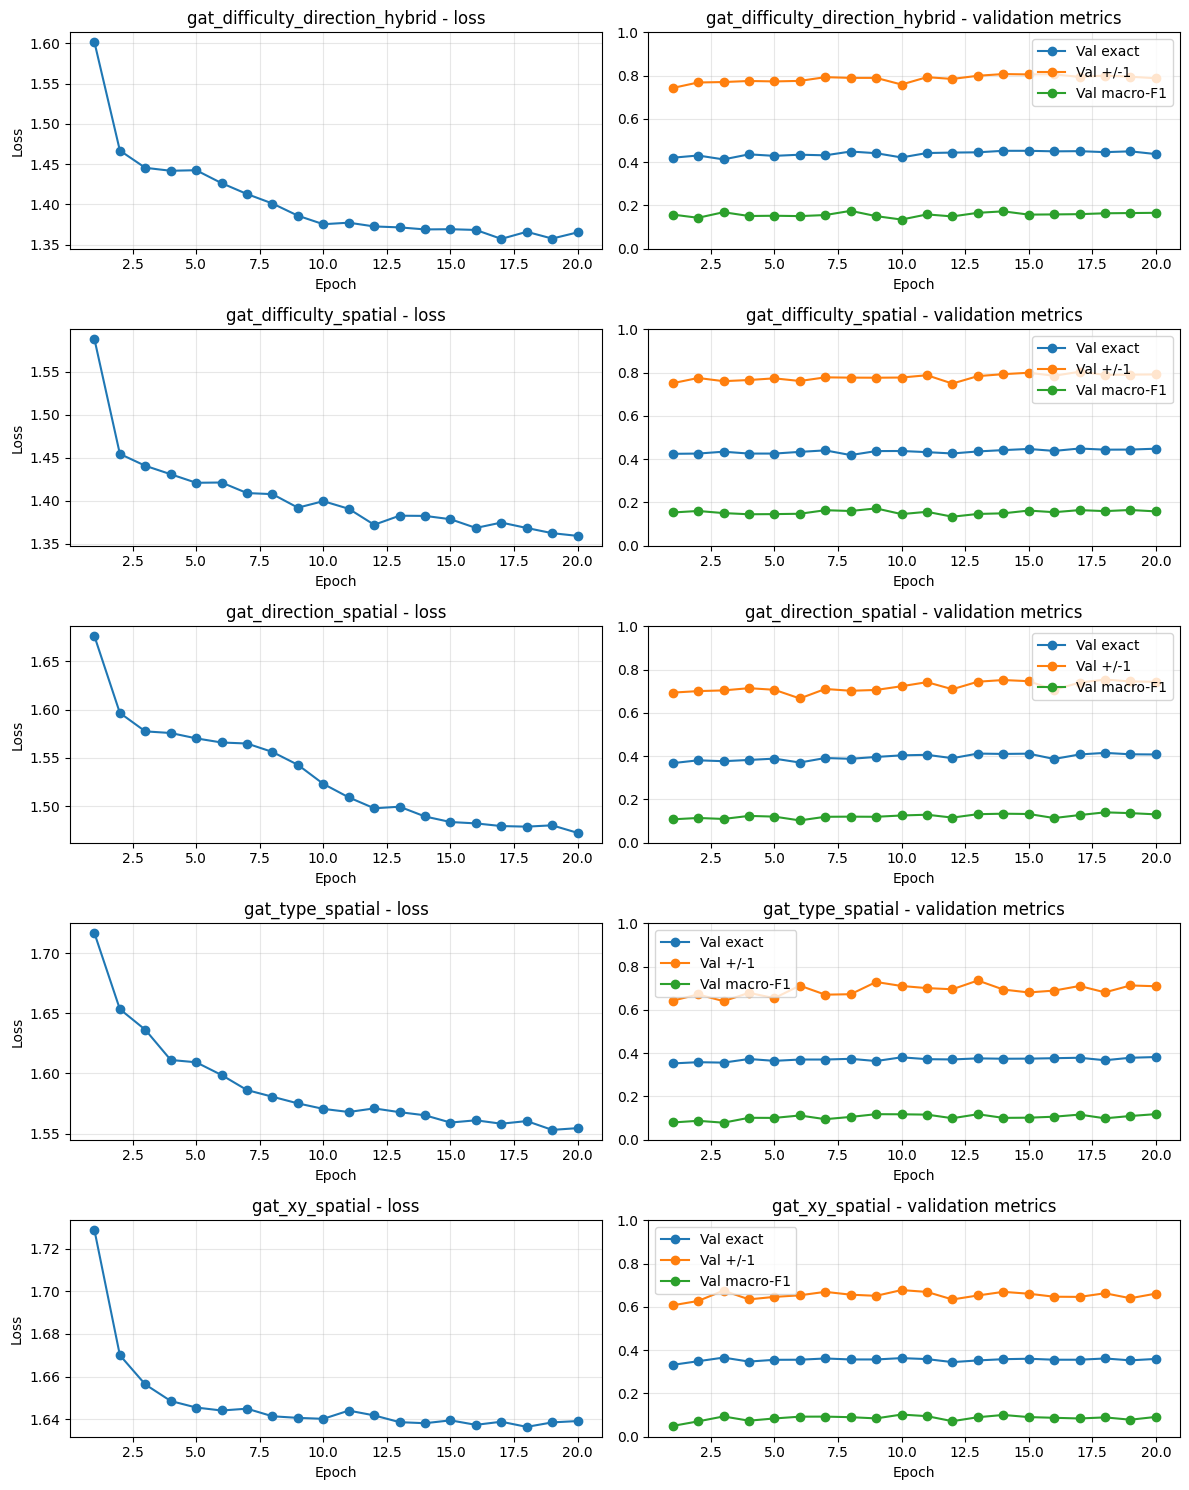

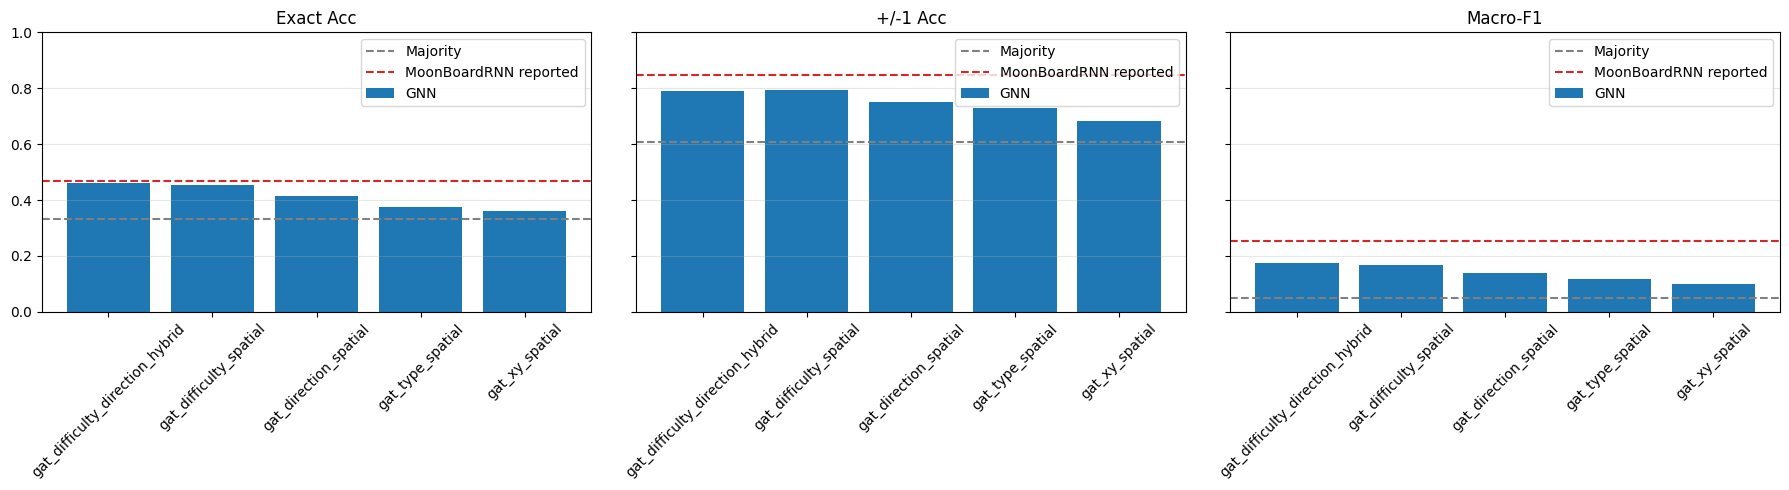

In [10]:
from pathlib import Path
import json

import matplotlib.pyplot as plt
import pandas as pd

def load_ablation_runs(ablation_root="outputs_ablation_main_scale"):
    ablation_root = Path(ablation_root)
    runs = []
    for result_path in sorted(ablation_root.glob("*/result.json")):
        run_dir = result_path.parent
        history_path = run_dir / "history.json"
        result = json.loads(result_path.read_text(encoding="utf-8"))
        history = json.loads(history_path.read_text(encoding="utf-8")) if history_path.exists() else []
        runs.append({"name": run_dir.name, "result": result, "history": history})
    if not runs:
        raise FileNotFoundError(f"No ablation result.json files found under {ablation_root}")
    return runs

def plot_ablation_histories(runs):
    n = len(runs)
    fig, axes = plt.subplots(n, 2, figsize=(12, max(3 * n, 4)), squeeze=False)
    for row, run in enumerate(runs):
        history = run["history"]
        if not history:
            axes[row][0].set_title(f"{run['name']} - no history")
            axes[row][1].axis("off")
            continue
        epochs = [h["epoch"] for h in history]
        axes[row][0].plot(epochs, [h["loss"] for h in history], marker="o")
        axes[row][0].set_title(f"{run['name']} - loss")
        axes[row][0].set_xlabel("Epoch")
        axes[row][0].set_ylabel("Loss")
        axes[row][0].grid(True, alpha=0.3)

        for key, label in [
            ("val_exact_acc", "Val exact"),
            ("val_relaxed_acc", "Val +/-1"),
            ("val_macro_f1", "Val macro-F1"),
        ]:
            axes[row][1].plot(epochs, [h[key] for h in history], marker="o", label=label)
        axes[row][1].set_title(f"{run['name']} - validation metrics")
        axes[row][1].set_xlabel("Epoch")
        axes[row][1].set_ylim(0, 1)
        axes[row][1].grid(True, alpha=0.3)
        axes[row][1].legend()
    plt.tight_layout()
    plt.show()

def ablation_summary_dataframe(runs):
    rows = []
    for run in runs:
        result = run["result"]
        config = result["config"]
        test = result["test_metrics"]
        majority = result["majority_baseline"]
        baseline = result.get("moonboardrnn_reported_baseline", {})
        rows.append({
            "run": run["name"],
            "feature_set": config["feature_set"],
            "edge_mode": config["edge_mode"],
            "exact": test["exact_acc"],
            "+/-1": test["relaxed_acc"],
            "macro_f1": test["macro_f1"],
            "majority_exact": majority["exact_acc"],
            "majority_+/-1": majority["relaxed_acc"],
            "majority_macro_f1": majority["macro_f1"],
            "rnn_exact": baseline.get("test_exact_acc"),
            "rnn_+/-1": baseline.get("test_plus_minus_1_acc"),
            "rnn_macro_f1": baseline.get("test_macro_f1"),
            "runtime_seconds": result["runtime_seconds"],
        })
    return pd.DataFrame(rows).sort_values(["exact", "+/-1", "macro_f1"], ascending=False)

def plot_ablation_metric_comparison(summary_df):
    metrics = [("exact", "Exact Acc"), ("+/-1", "+/-1 Acc"), ("macro_f1", "Macro-F1")]
    labels = summary_df["run"].tolist()
    fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=True)
    for ax, (metric, title) in zip(axes, metrics):
        ax.bar(labels, summary_df[metric], label="GNN")
        majority_col = {"exact": "majority_exact", "+/-1": "majority_+/-1", "macro_f1": "majority_macro_f1"}[metric]
        rnn_col = {"exact": "rnn_exact", "+/-1": "rnn_+/-1", "macro_f1": "rnn_macro_f1"}[metric]
        ax.axhline(summary_df[majority_col].iloc[0], color="gray", linestyle="--", label="Majority")
        if pd.notna(summary_df[rnn_col].iloc[0]):
            ax.axhline(summary_df[rnn_col].iloc[0], color="tab:red", linestyle="--", label="MoonBoardRNN reported")
        ax.set_title(title)
        ax.set_ylim(0, 1)
        ax.tick_params(axis="x", rotation=45)
        ax.grid(axis="y", alpha=0.3)
        ax.legend()
    plt.tight_layout()
    plt.show()

# Load, display, and plot all ablation results.
ablation_runs = load_ablation_runs("outputs_ablation_main_scale")
ablation_summary_df = ablation_summary_dataframe(ablation_runs)
display(ablation_summary_df)
plot_ablation_histories(ablation_runs)
plot_ablation_metric_comparison(ablation_summary_df)

## Interpreting Results

The current short-run GNN results should be treated as preliminary. They improve over simple majority/coordinate-only baselines, but the saved MoonBoardRNN GradeNet output is still higher. A final claim should be based on the controlled-scale run above and should state remaining differences: graph input versus sequence input, training schedule, and whether auxiliary hold difficulty features are used.
